In [1]:
import pandas as pd

# Read data from appoinments.csv

df = pd.read_csv("../data/appointments.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [2]:
#Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [3]:
#check missing values
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [4]:
# Show summary stats
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [5]:
# Make the names of columns to lowercase to make programming easeier

df.columns = df.columns.str.lower().str.replace("-", "_")
df.columns

Index(['patientid', 'appointmentid', 'gender', 'scheduledday',
       'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hipertension',
       'diabetes', 'alcoholism', 'handcap', 'sms_received', 'no_show'],
      dtype='object')

In [6]:
# Now here we convert the columns from string to datetime format to know the date and counting waiting time

df["scheduledday"] = pd.to_datetime(df["scheduledday"])
df["appointmentday"] = pd.to_datetime(df["appointmentday"])

df[["scheduledday", "appointmentday"]].head()

,scheduledday,appointmentday
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00


In [7]:
# Here we extract useful date features for congestion

df["appointment_date"] = df["appointmentday"].dt.date
df["appointment_day_of_week"] = df["appointmentday"].dt.dayofweek
df["appointment_month"] = df["appointmentday"].dt.month

df["waiting_days"] = (
    df["appointmentday"].dt.normalize() - df["scheduledday"].dt.normalize()
).dt.days

df[[
    "appointment_date",
    "appointment_day_of_week",
    "appointment_month",
    "waiting_days"
]].head()

,appointment_date,appointment_day_of_week,appointment_month,waiting_days
0,2016-04-29,4,4,0
1,2016-04-29,4,4,0
2,2016-04-29,4,4,0
3,2016-04-29,4,4,0
4,2016-04-29,4,4,0


In [8]:
# Remove invalid values

df = df[df["age"] >= 0]
df = df[df["waiting_days"] >= 0]

df.shape

(110521, 18)

In [9]:
# Create a daily dateset for clinic congestion prediction

clinic_df = df.groupby(["appointment_date", "neighbourhood"]).agg(
    total_appointments=("appointmentid", "count"),
    avg_age=("age", "mean"),
    diabetes_count=("diabetes", "sum"),
    hypertension_count=("hipertension", "sum"),
    sms_received_count=("sms_received", "sum"),
    avg_waiting_days=("waiting_days", "mean"),
    appointment_day_of_week=("appointment_day_of_week", "first"),
    appointment_month=("appointment_month", "first")
).reset_index()

clinic_df.head()

,appointment_date,neighbourhood,total_appointments,avg_age,diabetes_count,hypertension_count,sms_received_count,avg_waiting_days,appointment_day_of_week,appointment_month
0,2016-04-29,ANDORINHAS,83,34.674699,16,27,31,11.867470,4,4
1,2016-04-29,ANTÔNIO HONÓRIO,4,38.000000,0,0,1,10.000000,4,4
2,2016-04-29,ARIOVALDO FAVALESSA,8,29.500000,1,1,1,3.000000,4,4
3,2016-04-29,BARRO VERMELHO,7,38.571429,0,0,2,4.857143,4,4
4,2016-04-29,BELA VISTA,51,29.490196,2,10,16,11.117647,4,4


In [10]:
# Check the shape of the congestion dataset
clinic_df.shape

(2012, 10)

In [11]:
# Analyze appointment count distribution
clinic_df["total_appointments"].describe()

count    2012.000000
mean       54.930915
std        53.927781
min         1.000000
25%        16.000000
50%        38.000000
75%        81.000000
max       372.000000
Name: total_appointments, dtype: float64

In [12]:
# Create congestion levels
clinic_df["congestion_level"] = pd.qcut(
    clinic_df["total_appointments"],
    q=3,
    labels=["Low", "Medium", "High"]
)

clinic_df["congestion_level"].value_counts()

congestion_level
Low       681
Medium    667
High      664
Name: count, dtype: int64

In [13]:
# Display congestion example
clinic_df[[
    "appointment_date",
    "neighbourhood",
    "total_appointments",
    "congestion_level"
]].head(10)

,appointment_date,neighbourhood,total_appointments,congestion_level
0,2016-04-29,ANDORINHAS,83,High
1,2016-04-29,ANTÔNIO HONÓRIO,4,Low
2,2016-04-29,ARIOVALDO FAVALESSA,8,Low
3,2016-04-29,BARRO VERMELHO,7,Low
4,2016-04-29,BELA VISTA,51,Medium
5,2016-04-29,BENTO FERREIRA,30,Medium
6,2016-04-29,BOA VISTA,9,Low
7,2016-04-29,BONFIM,79,High
8,2016-04-29,CARATOÍRA,89,High
9,2016-04-29,CENTRO,109,High


In [14]:
# Select input features and target
features = [
    "avg_age",
    "diabetes_count",
    "hypertension_count",
    "sms_received_count",
    "avg_waiting_days",
    "appointment_day_of_week",
    "appointment_month"
]

X = clinic_df[features]
y = clinic_df["congestion_level"]

X.head()

,avg_age,diabetes_count,hypertension_count,sms_received_count,avg_waiting_days,appointment_day_of_week,appointment_month
0,34.674699,16,27,31,11.867470,4,4
1,38.000000,0,0,1,10.000000,4,4
2,29.500000,1,1,1,3.000000,4,4
3,38.571429,0,0,2,4.857143,4,4
4,29.490196,2,10,16,11.117647,4,4


In [15]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1609, 7)
Testing data: (403, 7)


In [16]:
# Scale input features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Results")
print(classification_report(y_test, log_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Results
              precision    recall  f1-score   support

        High       0.89      0.80      0.85       133
         Low       0.84      0.90      0.87       136
      Medium       0.74      0.76      0.75       134

    accuracy                           0.82       403
   macro avg       0.83      0.82      0.82       403
weighted avg       0.83      0.82      0.82       403

Confusion Matrix:
[[107   4  22]
 [  0 123  13]
 [ 13  19 102]]


In [18]:
# Train Decision Tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

print("Decision Tree Results")
print(classification_report(y_test, dt_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Results
              precision    recall  f1-score   support

        High       0.96      0.83      0.89       133
         Low       0.79      0.94      0.86       136
      Medium       0.79      0.73      0.76       134

    accuracy                           0.84       403
   macro avg       0.84      0.84      0.84       403
weighted avg       0.84      0.84      0.84       403

Confusion Matrix:
[[111   4  18]
 [  0 128   8]
 [  5  31  98]]


In [19]:
# Train KNN model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Results")
print(classification_report(y_test, knn_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

KNN Results
              precision    recall  f1-score   support

        High       0.92      0.86      0.89       133
         Low       0.75      0.89      0.81       136
      Medium       0.77      0.68      0.72       134

    accuracy                           0.81       403
   macro avg       0.81      0.81      0.81       403
weighted avg       0.81      0.81      0.81       403

Confusion Matrix:
[[114   4  15]
 [  3 121  12]
 [  7  36  91]]


In [20]:
# Train Neural Network model
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=500,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

nn_pred = nn_model.predict(X_test_scaled)

print("Neural Network Results")
print(classification_report(y_test, nn_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, nn_pred))

Neural Network Results
              precision    recall  f1-score   support

        High       0.94      0.90      0.92       133
         Low       0.92      0.94      0.93       136
      Medium       0.85      0.87      0.86       134

    accuracy                           0.90       403
   macro avg       0.90      0.90      0.90       403
weighted avg       0.90      0.90      0.90       403

Confusion Matrix:
[[120   1  12]
 [  0 128   8]
 [  8  10 116]]


In [21]:
# Encode target labels for PyTorch
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Encoded labels example:", y_train_encoded[:10])

Classes: ['High' 'Low' 'Medium']
Encoded labels example: [2 2 0 2 2 1 0 0 2 2]


In [22]:
# Convert training and testing data to PyTorch tensors
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([1609, 7])
torch.Size([1609])


In [23]:
# Build a PyTorch Neural Network model
import torch.nn as nn

class CongestionNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CongestionNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]
num_classes = len(label_encoder.classes_)

torch_model = CongestionNN(input_size, num_classes)

torch_model

CongestionNN(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

In [24]:
# Define loss function and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(torch_model.parameters(), lr=0.01)

In [25]:
# Train the PyTorch Neural Network model
epochs = 200

for epoch in range(epochs):
    torch_model.train()

    outputs = torch_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [20/200], Loss: 0.5676
Epoch [40/200], Loss: 0.4068
Epoch [60/200], Loss: 0.3315
Epoch [80/200], Loss: 0.2910
Epoch [100/200], Loss: 0.2643
Epoch [120/200], Loss: 0.2407
Epoch [140/200], Loss: 0.2191
Epoch [160/200], Loss: 0.1999
Epoch [180/200], Loss: 0.1845
Epoch [200/200], Loss: 0.1737


In [26]:
# Evaluate the PyTorch model
from sklearn.metrics import classification_report, confusion_matrix

torch_model.eval()

with torch.no_grad():
    test_outputs = torch_model(X_test_tensor)
    _, torch_pred_encoded = torch.max(test_outputs, 1)

torch_pred = label_encoder.inverse_transform(torch_pred_encoded.numpy())

print("PyTorch Neural Network Results")
print(classification_report(y_test, torch_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, torch_pred))

PyTorch Neural Network Results
              precision    recall  f1-score   support

        High       0.88      0.91      0.90       133
         Low       0.91      0.93      0.92       136
      Medium       0.85      0.80      0.82       134

    accuracy                           0.88       403
   macro avg       0.88      0.88      0.88       403
weighted avg       0.88      0.88      0.88       403

Confusion Matrix:
[[121   2  10]
 [  0 127   9]
 [ 16  11 107]]


In [27]:
# Compare model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, log_pred),
        "Precision": precision_score(y_test, log_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, log_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, log_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, dt_pred),
        "Precision": precision_score(y_test, dt_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, dt_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, dt_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "KNN",
        "Accuracy": accuracy_score(y_test, knn_pred),
        "Precision": precision_score(y_test, knn_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, knn_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, knn_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "Neural Network",
        "Accuracy": accuracy_score(y_test, nn_pred),
        "Precision": precision_score(y_test, nn_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, nn_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, nn_pred, average="weighted", zero_division=0)
    },
    {
        "Model": "PyTorch Neural Network",
        "Accuracy": accuracy_score(y_test, torch_pred),
        "Precision": precision_score(y_test, torch_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, torch_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_test, torch_pred, average="weighted", zero_division=0)
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.823821,0.826138,0.823821,0.823839
1,Decision Tree,0.836228,0.843593,0.836228,0.835777
2,KNN,0.808933,0.813460,0.808933,0.807903
3,Neural Network,0.903226,0.903769,0.903226,0.903333
4,PyTorch Neural Network,0.880893,0.879981,0.880893,0.880047


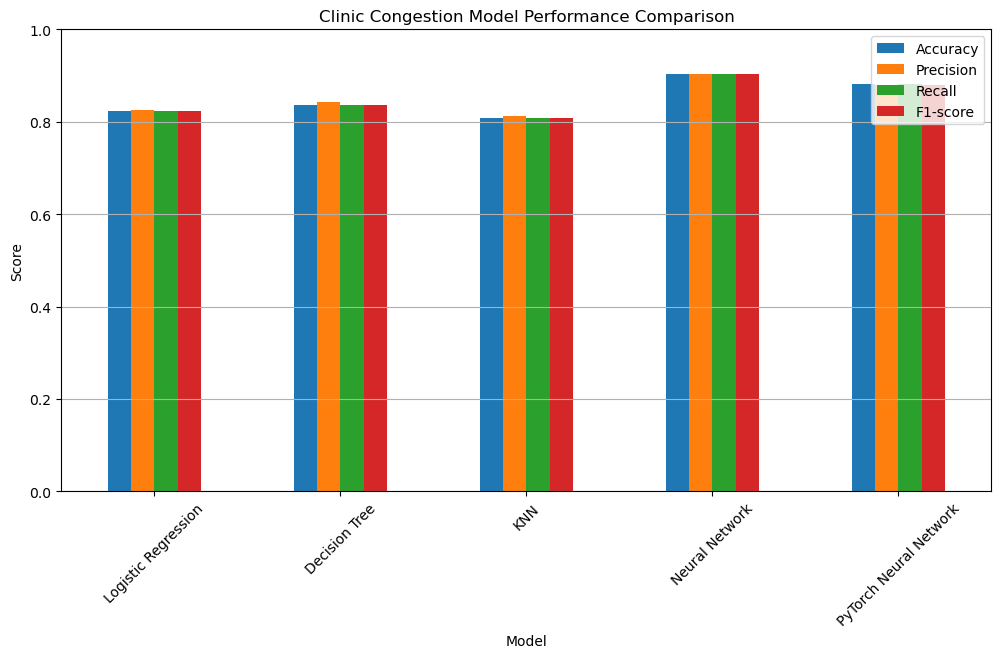

In [28]:
# Visualize final model performance comparison
import matplotlib.pyplot as plt

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Clinic Congestion Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

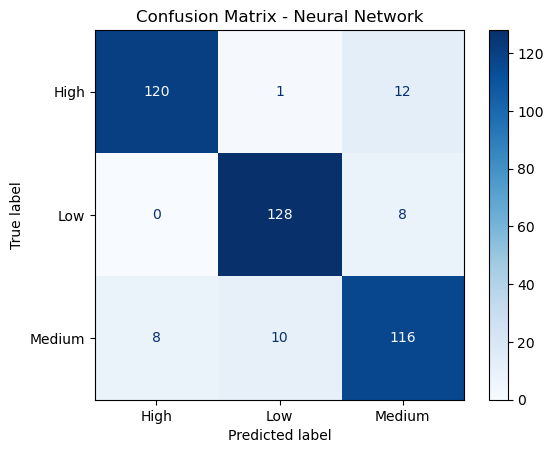

In [29]:
# Visualize confusion matrix for the best model
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Neural Network")
plt.show()

In [30]:
# Save the best model and scaler
import joblib

joblib.dump(nn_model, "../models/congestion_model.pkl")
joblib.dump(scaler, "../models/congestion_scaler.pkl")
joblib.dump(features, "../models/congestion_features.pkl")

['../models/congestion_features.pkl']